#Library


In [1]:
import os, random
import numpy as np
import pandas as pd
from glob import glob

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# =========================================
# PATH DATASET
# =========================================
BASE_DIR = r"E:\DATASET"

DATA_DIR = r"E:\DATASET\tomato"

# folder train dan validation
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")

# =========================================
# CEK PATH
# =========================================
print("TRAIN_DIR :", TRAIN_DIR)
print("VAL_DIR   :", VAL_DIR)

print("\nTrain Exist :", os.path.exists(TRAIN_DIR))
print("Val Exist   :", os.path.exists(VAL_DIR))


TRAIN_DIR : E:\DATASET\tomato\train
VAL_DIR   : E:\DATASET\tomato\val

Train Exist : True
Val Exist   : True


#EDA

                                               Train  Validation
Tomato___Bacterial_spot                         1000         100
Tomato___Early_blight                           1000         100
Tomato___Late_blight                            1000         100
Tomato___Leaf_Mold                              1000         100
Tomato___Septoria_leaf_spot                     1000         100
Tomato___Spider_mites Two-spotted_spider_mite   1000         100
Tomato___Target_Spot                            1000         100
Tomato___Tomato_Yellow_Leaf_Curl_Virus          1000         100
Tomato___Tomato_mosaic_virus                    1000         100
Tomato___healthy                                1000         100


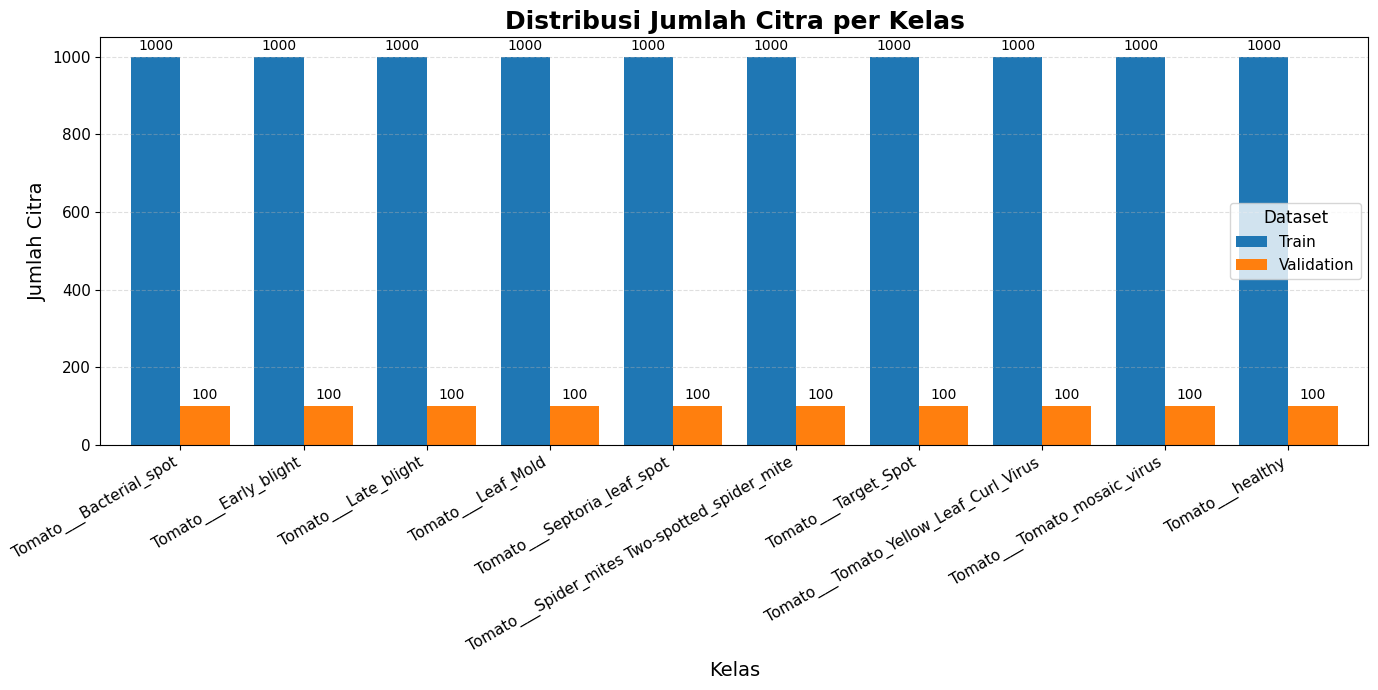

In [2]:
import os
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
# =========================================
# FUNGSI HITUNG JUMLAH CITRA
# =========================================
def count_images_per_class(data_dir):
    class_counts = {}

    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)

        if os.path.isdir(class_path):
            total_images = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])

            class_counts[class_name] = total_images

    return class_counts

# =========================================
# HITUNG DISTRIBUSI
# =========================================
train_counts = count_images_per_class(TRAIN_DIR)
val_counts   = count_images_per_class(VAL_DIR)

# =========================================
# GABUNGKAN KE DATAFRAME
# =========================================
df_dist = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
}).fillna(0).astype(int)

print(df_dist)

# =========================================
# VISUALISASI DISTRIBUSI CITRA YANG LEBIH RAPI
# =========================================

# Membuat plot
ax = df_dist.plot(
    kind='bar',
    figsize=(14,7),
    width=0.8
)

# Judul dan label
plt.title(
    "Distribusi Jumlah Citra per Kelas",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Kelas",
    fontsize=14
)

plt.ylabel(
    "Jumlah Citra",
    fontsize=14
)

# Mengatur nama kelas agar tidak terpotong
plt.xticks(
    rotation=30,      # Miringkan tulisan
    ha='right',       # Posisi rata kanan
    fontsize=11
)

plt.yticks(fontsize=11)

# Grid lebih halus
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

# Legend
plt.legend(
    title="Dataset",
    fontsize=11,
    title_fontsize=12
)

# Menampilkan jumlah di atas bar
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=10,
        padding=3
    )

# Supaya layout tidak kepotong
plt.tight_layout()

# Tampilkan
plt.show()

In [3]:
# =========================================
# CEK UKURAN CITRA DATASET
# =========================================

import os
from PIL import Image
import pandas as pd

# =========================================
# FUNGSI CEK UKURAN CITRA
# =========================================
def check_image_sizes(data_dir):

    image_info = []

    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)

        if os.path.isdir(class_path):

            for file_name in os.listdir(class_path):

                if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):

                    img_path = os.path.join(class_path, file_name)

                    try:
                        with Image.open(img_path) as img:
                            width, height = img.size

                        image_info.append({
                            "Class": class_name,
                            "Image": file_name,
                            "Width": width,
                            "Height": height,
                            "Size": f"{width} x {height}"
                        })

                    except Exception as e:
                        print(f"Error membaca {img_path}: {e}")

    return pd.DataFrame(image_info)

# =========================================
# JALANKAN
# =========================================
df_sizes = check_image_sizes(TRAIN_DIR)

# =========================================
# TAMPILKAN HASIL
# =========================================
print(df_sizes.head())

# =========================================
# CEK DISTRIBUSI UKURAN
# =========================================
print("\nJumlah masing-masing ukuran citra:\n")
print(df_sizes["Size"].value_counts())

                     Class                                              Image  \
0  Tomato___Bacterial_spot  00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_B...   
1  Tomato___Bacterial_spot  01375198-62af-4c40-bddf-f3c11107200b___GCREC_B...   
2  Tomato___Bacterial_spot  05777829-6912-44bb-bcef-901bc5190584___GCREC_B...   
3  Tomato___Bacterial_spot  070228e2-ba4e-4de8-813b-074e51ed6f5a___UF.GRC_...   
4  Tomato___Bacterial_spot  07238109-52ed-4369-b16c-6f5844858b81___UF.GRC_...   

   Width  Height       Size  
0    256     256  256 x 256  
1    256     256  256 x 256  
2    256     256  256 x 256  
3    256     256  256 x 256  
4    256     256  256 x 256  

Jumlah masing-masing ukuran citra:

Size
256 x 256    10000
Name: count, dtype: int64


In [4]:
# =========================================
# DETEKSI DAN TAMPILKAN GAMBAR RUSAK
# =========================================

import os
from PIL import Image
import matplotlib.pyplot as plt

# =========================================
# CEK GAMBAR RUSAK
# =========================================
def find_corrupted_images(data_dir):

    corrupted_images = []

    for class_name in sorted(os.listdir(data_dir)):

        class_path = os.path.join(data_dir, class_name)

        if os.path.isdir(class_path):

            for file_name in os.listdir(class_path):

                if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):

                    img_path = os.path.join(class_path, file_name)

                    try:
                        img = Image.open(img_path)
                        img.verify()  # Verifikasi file gambar

                    except Exception as e:

                        corrupted_images.append({
                            "class": class_name,
                            "file": file_name,
                            "path": img_path,
                            "error": str(e)
                        })

    return corrupted_images

# =========================================
# CEK DATASET
# =========================================
corrupted = find_corrupted_images(TRAIN_DIR)

# =========================================
# HASIL
# =========================================
print(f"Jumlah gambar rusak: {len(corrupted)}\n")

# =========================================
# TAMPILKAN DETAIL
# =========================================
for i, img_info in enumerate(corrupted):

    print(f"{i+1}.")
    print(f"Kelas : {img_info['class']}")
    print(f"File  : {img_info['file']}")
    print(f"Path  : {img_info['path']}")
    print(f"Error : {img_info['error']}")
    print("-" * 50)

Jumlah gambar rusak: 0



In [5]:
# =========================================
#  CEK FORMAT GAMBAR
# =========================================
def check_image_formats(data_dir):

    image_formats = []

    for class_name in sorted(os.listdir(data_dir)):

        class_path = os.path.join(data_dir, class_name)

        if os.path.isdir(class_path):

            for file_name in os.listdir(class_path):

                img_path = os.path.join(class_path, file_name)

                try:
                    with Image.open(img_path) as img:

                        image_formats.append({
                            "Class": class_name,
                            "File": file_name,
                            "Format": img.format,
                            "Mode": img.mode
                        })

                except Exception as e:

                    image_formats.append({
                        "Class": class_name,
                        "File": file_name,
                        "Format": "ERROR",
                        "Mode": str(e)
                    })

    return pd.DataFrame(image_formats)

# =========================================
# JALANKAN
# =========================================
df_formats = check_image_formats(TRAIN_DIR)

# =========================================
# TAMPILKAN DATA
# =========================================
print(df_formats.head())

# =========================================
# HITUNG JUMLAH FORMAT
# =========================================
print("\nDistribusi Format Gambar:\n")
print(df_formats["Format"].value_counts())

                     Class                                               File  \
0  Tomato___Bacterial_spot  00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_B...   
1  Tomato___Bacterial_spot  01375198-62af-4c40-bddf-f3c11107200b___GCREC_B...   
2  Tomato___Bacterial_spot  05777829-6912-44bb-bcef-901bc5190584___GCREC_B...   
3  Tomato___Bacterial_spot  070228e2-ba4e-4de8-813b-074e51ed6f5a___UF.GRC_...   
4  Tomato___Bacterial_spot  07238109-52ed-4369-b16c-6f5844858b81___UF.GRC_...   

  Format Mode  
0   JPEG  RGB  
1   JPEG  RGB  
2   JPEG  RGB  
3   JPEG  RGB  
4   JPEG  RGB  

Distribusi Format Gambar:

Format
JPEG    10000
Name: count, dtype: int64


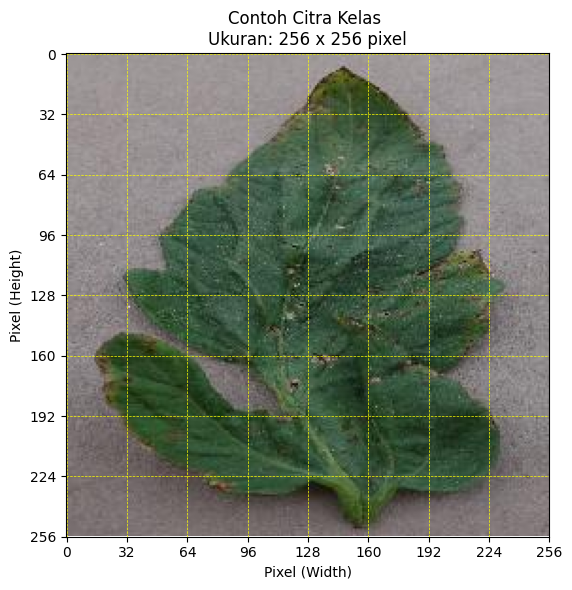

Informasi Citra
------------------------------
Nama File : bakteri_tomat.jpg
Ukuran    : 256 x 256 pixel
Mode      : RGB
Format    : JPEG


In [6]:
# =========================================
# AMBIL 1 CONTOH GAMBAR
# =========================================

# Ganti dengan path gambar Anda
IMG_PATH = r"E:\DATASET\tomato\train\Tomato___Bacterial_spot\bakteri_tomat.jpg"

# =========================================
# BUKA GAMBAR
# =========================================
img = Image.open(IMG_PATH)

# Ambil ukuran pixel
width, height = img.size

# =========================================
# TAMPILKAN GAMBAR
# =========================================

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Contoh Citra Kelas \nUkuran: {img.size[0]} x {img.size[1]} pixel")

# Aktifkan grid pixel
plt.xticks(np.linspace(0, img.size[0], 9))
plt.yticks(np.linspace(0, img.size[1], 9))
plt.grid(color="yellow", linestyle="--", linewidth=0.5)

plt.xlabel("Pixel (Width)")
plt.ylabel("Pixel (Height)")
plt.tight_layout()
plt.show()

# =========================================
# CETAK INFORMASI
# =========================================
print("Informasi Citra")
print("-" * 30)
print(f"Nama File : {os.path.basename(IMG_PATH)}")
print(f"Ukuran    : {width} x {height} pixel")
print(f"Mode      : {img.mode}")
print(f"Format    : {img.format}")

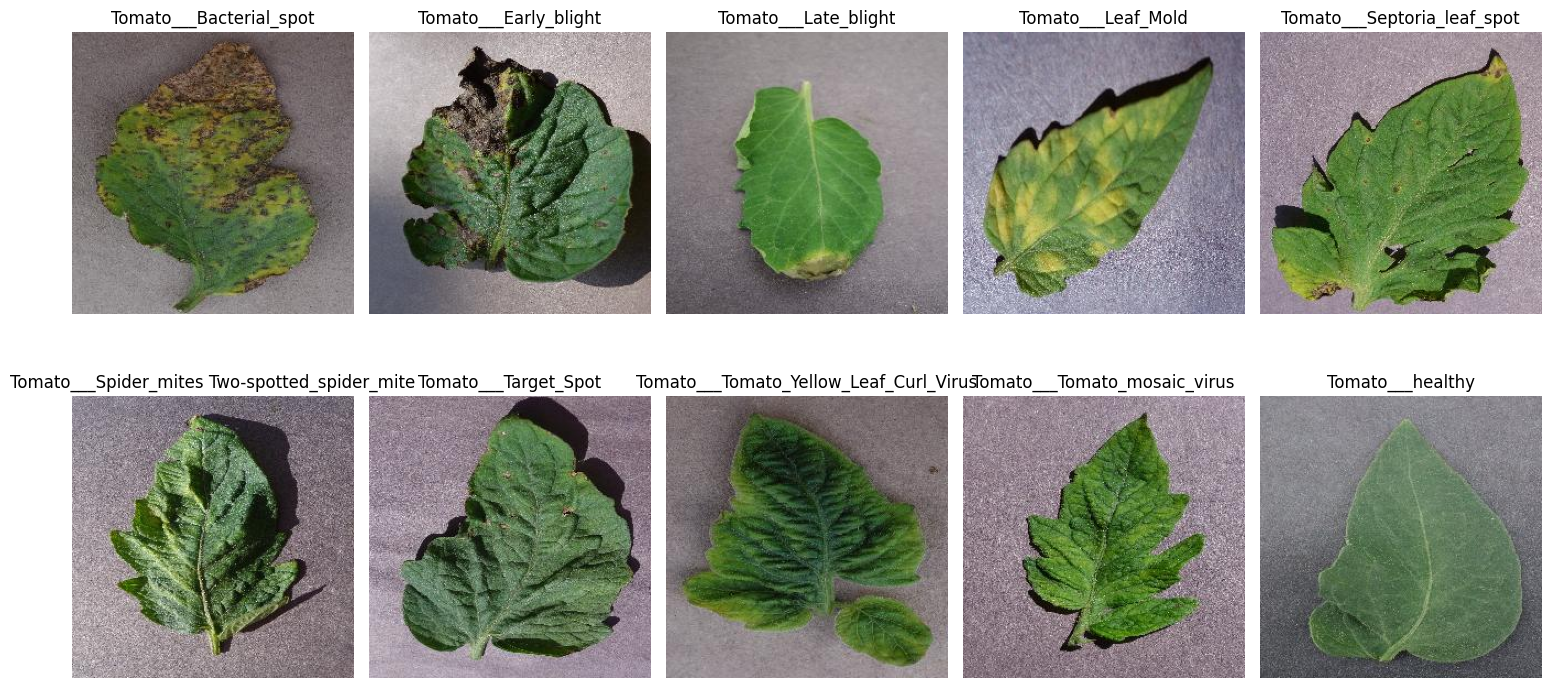

In [ ]:
plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):
    img_path = os.path.join(train_path, cls, os.listdir(os.path.join(train_path, cls))[0])
    img = Image.open(img_path)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()


#RESIZE GAMBAR

In [7]:

import os

# ===============================
# INPUT DIRECTORY (DATASET ASLI)
# ===============================
INPUT_BASE_DIR = r"E:\DATASET\tomato"
INPUT_TRAIN_DIR = os.path.join(INPUT_BASE_DIR, 'train')
INPUT_VAL_DIR   = os.path.join(INPUT_BASE_DIR, 'val')

# ===============================
# OUTPUT DIRECTORY (HASIL PROSES)
# ===============================
OUTPUT_BASE_DIR = r"E:\DATASET\tomato_resize2"
OUTPUT_TRAIN_DIR = os.path.join(OUTPUT_BASE_DIR, 'train')
OUTPUT_VAL_DIR   = os.path.join(OUTPUT_BASE_DIR, 'val')

# ===============================
# BUAT FOLDER JIKA BELUM ADA
# ===============================
os.makedirs(OUTPUT_TRAIN_DIR, exist_ok=True)
os.makedirs(OUTPUT_VAL_DIR, exist_ok=True)

# ===============================
# INFORMASI PATH
# ===============================
print("Input directory (train):", INPUT_TRAIN_DIR)
print("Input directory (val)  :", INPUT_VAL_DIR)
print("Output directory       :", OUTPUT_BASE_DIR)


Input directory (train): E:\DATASET\tomato\train
Input directory (val)  : E:\DATASET\tomato\val
Output directory       : E:\DATASET\tomato_resize2


In [8]:
import os
import cv2

def process_and_save_image(
    row,
    input_base_dir,
    output_base_dir,
    target_size=(224, 224)
):
    """
    row   : dict / Series dengan key ['path', 'label', 'split']
    split : 'train' atau 'val'
    """

    # Ambil informasi dari row
    original_path = row['path']
    label = row['label']
    split = row['split']   # train / val

    # ===============================
    # OUTPUT DIRECTORY (Drive)
    # ===============================
    output_split_dir = os.path.join(output_base_dir, split)
    output_label_dir = os.path.join(output_split_dir, label)
    os.makedirs(output_label_dir, exist_ok=True)

    # ===============================
    # NAMA FILE
    # ===============================
    filename = os.path.basename(original_path)
    output_path = os.path.join(output_label_dir, filename)

    # ===============================
    # READ → RESIZE → SAVE
    # ===============================
    img = cv2.imread(original_path)

    if img is not None:
        img_resized = cv2.resize(
            img,
            target_size,
            interpolation=cv2.INTER_AREA
        )
        cv2.imwrite(output_path, img_resized)
    else:
        print(f"⚠️ Warning: Could not read image at {original_path}")

    return output_path


In [9]:
import os
import pandas as pd
from tqdm import tqdm

tqdm.pandas(desc="Processing and saving images")

data = []

# Process train directory
for label in os.listdir(INPUT_TRAIN_DIR):
    class_path = os.path.join(INPUT_TRAIN_DIR, label)
    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                data.append({
                    'path': os.path.join(class_path, img_file),
                    'label': label,
                    'split': 'train'
                })

# Process validation directory
for label in os.listdir(INPUT_VAL_DIR):
    class_path = os.path.join(INPUT_VAL_DIR, label)
    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                data.append({
                    'path': os.path.join(class_path, img_file),
                    'label': label,
                    'split': 'val'
                })

df = pd.DataFrame(data)

# Now, apply the processing function
df['processed_path'] = df.progress_apply(
    lambda row: process_and_save_image(
        row=row,
        input_base_dir=INPUT_BASE_DIR,        # konsisten dengan setup sebelumnya
        output_base_dir=OUTPUT_BASE_DIR,
        target_size=(224, 224)
    ),
    axis=1
)
print("\nPreprocessing complete. First 5 rows of DataFrame with new paths:")
display(df.head())

Processing and saving images: 100%|█████████████████████████████████████████████| 11000/11000 [00:31<00:00, 351.07it/s]


Preprocessing complete. First 5 rows of DataFrame with new paths:


,path,label,split,processed_path
0,E:\DATASET\tomato\train\Tomato___Bacterial_spo...,Tomato___Bacterial_spot,train,E:\DATASET\tomato_resize2\train\Tomato___Bacte...
1,E:\DATASET\tomato\train\Tomato___Bacterial_spo...,Tomato___Bacterial_spot,train,E:\DATASET\tomato_resize2\train\Tomato___Bacte...
2,E:\DATASET\tomato\train\Tomato___Bacterial_spo...,Tomato___Bacterial_spot,train,E:\DATASET\tomato_resize2\train\Tomato___Bacte...
3,E:\DATASET\tomato\train\Tomato___Bacterial_spo...,Tomato___Bacterial_spot,train,E:\DATASET\tomato_resize2\train\Tomato___Bacte...
4,E:\DATASET\tomato\train\Tomato___Bacterial_spo...,Tomato___Bacterial_spot,train,E:\DATASET\tomato_resize2\train\Tomato___Bacte...


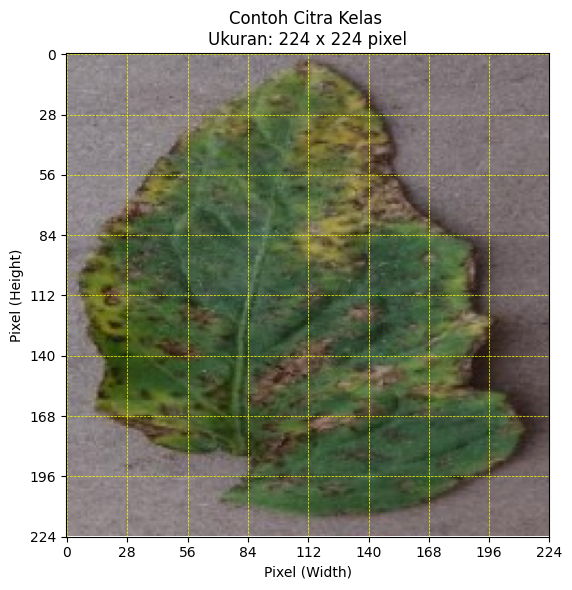

Informasi Citra
------------------------------
Nama File : bakterialspot69.jpg
Ukuran    : 224 x 224 pixel
Mode      : RGB
Format    : JPEG


In [10]:
# =========================================
# AMBIL 1 CONTOH GAMBAR
# =========================================

# Ganti dengan path gambar Anda
IMG_PATH = r"E:\DATASET\tomato_resize2\train\Tomato___Bacterial_spot\bakterialspot69.jpg"

# =========================================
# BUKA GAMBAR
# =========================================
img = Image.open(IMG_PATH)

# Ambil ukuran pixel
width, height = img.size

# =========================================
# TAMPILKAN GAMBAR
# =========================================

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Contoh Citra Kelas \nUkuran: {img.size[0]} x {img.size[1]} pixel")

# Aktifkan grid pixel
plt.xticks(np.linspace(0, img.size[0], 9))
plt.yticks(np.linspace(0, img.size[1], 9))
plt.grid(color="yellow", linestyle="--", linewidth=0.5)

plt.xlabel("Pixel (Width)")
plt.ylabel("Pixel (Height)")
plt.tight_layout()
plt.show()

# =========================================
# CETAK INFORMASI
# =========================================
print("Informasi Citra")
print("-" * 30)
print(f"Nama File : {os.path.basename(IMG_PATH)}")
print(f"Ukuran    : {width} x {height} pixel")
print(f"Mode      : {img.mode}")
print(f"Format    : {img.format}")

#DATA SPLIT

In [14]:
import os
import random
import shutil
from tqdm import tqdm


In [16]:
BASE_DIR = "/content/drive/MyDrive/SKRIPSI/DATASET2/tomato_resize"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")   # tidak diubah
TEST_DIR  = os.path.join(BASE_DIR, "test")  # akan dibuat

SPLIT_RATIO = 0.10  # 10% untuk test
random.seed(42)     # agar reproducible


In [17]:
def split_train_to_test(train_dir, test_dir, split_ratio):
    classes = os.listdir(train_dir)

    for cls in classes:
        class_train_path = os.path.join(train_dir, cls)
        images = [f for f in os.listdir(class_train_path)
                  if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

        random.shuffle(images)
        test_size = int(len(images) * split_ratio)

        test_images = images[:test_size]

        class_test_path = os.path.join(test_dir, cls)
        os.makedirs(class_test_path, exist_ok=True)

        for img in test_images:
            src = os.path.join(class_train_path, img)
            dst = os.path.join(class_test_path, img)
            shutil.move(src, dst)  # PINDAH FISIK KE DRIVE

In [18]:
split_train_to_test(TRAIN_DIR, TEST_DIR, SPLIT_RATIO)
print("Split selesai: 10% data train dipindahkan ke folder test.")

Split selesai: 10% data train dipindahkan ke folder test.


In [19]:
def count_images(directory):
    total = 0
    for root, _, files in os.walk(directory):
        total += len(files)
    return total

print("Jumlah data TRAIN:", count_images(TRAIN_DIR))
print("Jumlah data VAL  :", count_images(VAL_DIR))
print("Jumlah data TEST :", count_images(TEST_DIR))

Jumlah data TRAIN: 9006
Jumlah data VAL  : 1001
Jumlah data TEST : 1000


Distribusi Jumlah Citra:



,Train,Validation,Test
Tomato___Bacterial_spot,901,100,100
Tomato___Early_blight,901,100,100
Tomato___Late_blight,900,100,100
Tomato___Leaf_Mold,903,100,100
Tomato___Septoria_leaf_spot,901,100,100
Tomato___Spider_mites Two-spotted_spider_mite,900,101,100
Tomato___Target_Spot,900,100,100
Tomato___Tomato_Yellow_Leaf_Curl_Virus,900,100,100
Tomato___Tomato_mosaic_virus,900,100,100
Tomato___healthy,900,100,100


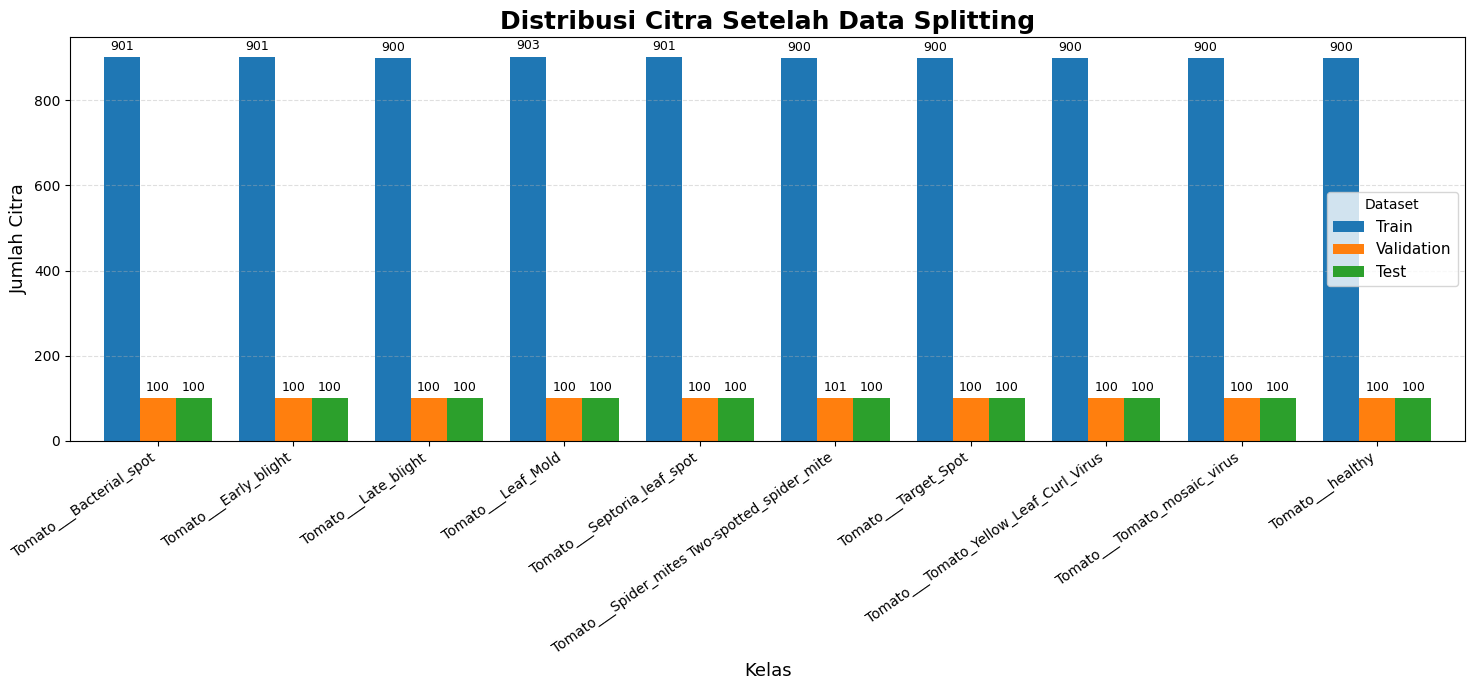


Total Data:
Train      : 9006
Validation : 1001
Test       : 1000


In [11]:
# =========================================
# VISUALISASI DISTRIBUSI DATA
# SETELAH SPLIT TRAIN / VAL / TEST
# =========================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# PATH DATASET
# =========================================
TRAIN_DIR = r"E:\DATASET\Tomato_Resize\train"
VAL_DIR   = r"E:\DATASET\Tomato_Resize\val"
TEST_DIR  = r"E:\DATASET\Tomato_Resize\test"

# =========================================
# FUNGSI HITUNG JUMLAH CITRA
# =========================================
def count_images(data_dir):

    class_counts = {}

    for class_name in sorted(os.listdir(data_dir)):

        class_path = os.path.join(data_dir, class_name)

        if os.path.isdir(class_path):

            total = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])

            class_counts[class_name] = total

    return class_counts

# =========================================
# HITUNG DISTRIBUSI
# =========================================
train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

# =========================================
# GABUNGKAN KE DATAFRAME
# =========================================
df_dist = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
}).fillna(0).astype(int)

# =========================================
# TAMPILKAN TABEL
# =========================================
print("Distribusi Jumlah Citra:\n")
display(df_dist)

# =========================================
# VISUALISASI
# =========================================
ax = df_dist.plot(
    kind='bar',
    figsize=(15,7),
    width=0.8
)

# Judul
plt.title(
    "Distribusi Citra Setelah Data Splitting",
    fontsize=18,
    fontweight='bold'
)

# Label
plt.xlabel("Kelas", fontsize=13)
plt.ylabel("Jumlah Citra", fontsize=13)

# Rotasi nama kelas
plt.xticks(
    rotation=35,
    ha='right',
    fontsize=10
)

plt.yticks(fontsize=10)

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

# Legend
plt.legend(
    title='Dataset',
    fontsize=11
)

# Label jumlah pada bar
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

# =========================================
# TOTAL DATA
# =========================================
print("\nTotal Data:")
print(f"Train      : {sum(train_counts.values())}")
print(f"Validation : {sum(val_counts.values())}")
print(f"Test       : {sum(test_counts.values())}")